### EDIT DESCRIPTION

**Description**

Compute, per grid point and per assigned months:

1- number of timesteps within "impact area" masks (circle, IA01, IA02, dyn_feats),

2- number of timesteps satisfying extreme and compound definitions,

3- combinations of 1 and 2.


Plot in *code_for_plotting/paper/figures_stats_paper* and *code_for_plotting/paper/figures_dynfeats_paper*.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

import QS_functions as QSfunc
import compound_functions_alice as cfa

Parameter selection

In [24]:
# Variable
var_name = 'precip_6h'
# Radius of impact
r_impact = 500  # km

In [25]:
# Months selections, Start and end dates, Time intervals
# months = [] for all months
months_list = [[],[12,1,2],[3,4,5],[6,7,8],[9,10,11]]

t_start = '1979-01-01T00'
t_end = '2021-01-01'
t_int = 6
t_int_u = 'h'
t_last = np.array(t_end, dtype='datetime64') - np.timedelta64(t_int, t_int_u)
t_last = str(t_last)[:10]

# Time variable
time_allyear = cfa.timerange_datetime(t_start,t_end,t_int,t_int_u, [])

In [26]:
# Data location
data_dir = '/media/alice/Crucial X9/portal/data_UNIBE/Bern_data/'
out_dir = '.' #'/scratch2/aportal/processed_data/count_maps/'
fig_dir = '.' #'/home/aportal/figures/compound-extr/'

Grid, thresholds

In [27]:
# Not applicable at the moment
# # Lat and lon
# ds_thresh = xr.open_dataset(data_dir+'/processed_data/percentiles/percentiles_precip_6h_alice.nc')
# lat = ds_thresh['lat']
# lon = ds_thresh['lon']
# nlat = len(lat)
# nlon = len(lon)
# # grid
# X,Y = np.meshgrid(lon, lat)
# XY_tuples = np.array([X, Y]).reshape(2,len(lat)*len(lon)).transpose()
# 
# # Thresholds
# thld = np.zeros((nvar,len(lat),len(lon)))
# 
# if l_conv==True:
#     ivar=1
#     thld[0] = low_lims[0]
# else:
#     ivar=0
# 
# for iv in range(ivar,nvar):
#     ds = xr.open_dataset(data_dir+'/processed_data/percentiles/percentiles_'+var_list[iv]+'_alice.nc')
#     if ((len(ds['lat'])==nlat) and (len(ds['lon'])==nlon)) and \
#         ((ds['lat'] == lat).all()) and ((ds['lon'] == lon).all()):
#         ds_thresh = ds
#     else:
#         ds_thresh = ds.interp(
#             lon=lon, lat=lat, 
#             method='linear',
#             kwargs={'bounds_error':False,'fill_value': np.nan}    # nan values outside input grid
#             )
#     var_thresh = ds_thresh[cfa.str_to_name(var_list[iv])].sel(quantile=qtls[iv])
#     thld[iv] = np.maximum(var_thresh,low_lims[iv]).data

Storm selection

In [28]:
# Selection entries
id_storm = 0
cluster_number=0
# Open track datasets
df_metrics = pd.read_csv('../output/TRACKS_CL5_QS_6h_Medcrossers.csv', header=0)
# Select tracks as in time variable
df_metrics_6hfreq = QSfunc.get_storms_sometime(df_metrics, id_storm, [time_allyear])
print(df_metrics_6hfreq.head())
# Time selection
time_df = QSfunc.make_var_time(df_metrics_6hfreq)

   id    lon     lat  year  month  day  time      hPa  FT_MED_VEL_v  \
0   4  0.960  40.700  1979      1    8    18  1016.93        31.008   
1   4  2.486  40.678  1979      1    9     0  1015.56        31.008   
2   4  3.946  41.310  1979      1    9     6  1011.65        31.008   
3   4  5.837  41.596  1979      1    9    12  1008.73        31.008   
4   4  8.589  41.813  1979      1    9    18  1005.48        31.008   

   FT_MED_VEL_q  ...  AT_MED_VEL_c.1  AT_DIST_v.1  AT_DIST_q.1  AT_DIST_c.1  \
0         0.831  ...             2.0      131.844        0.529          2.0   
1         0.831  ...             0.0      161.318        0.649          0.0   
2         0.831  ...             0.0      166.135        0.665          0.0   
3         0.831  ...             0.0      233.856        0.843          0.0   
4         0.831  ...             0.0      226.829        0.829          0.0   

   AT_RAD_DIST_v.1  AT_RAD_DIST_q.1  AT_RAD_DIST_c.1  AT_CIRCLE_DIST_v  \
0          424.645      

SEGMENT-BASED IMPACT

Accumulate cyclone induced precipitation, for ALL/SLOW/MEDIAN/FAST

In [29]:
# Save indices where AT_MED_VEL_c==1/2/3
indices_slow = df_metrics_6hfreq[df_metrics_6hfreq['AT_MED_VEL_c']==1.0].index
indices_median = df_metrics_6hfreq[df_metrics_6hfreq['AT_MED_VEL_c']==2.0].index
indices_fast = df_metrics_6hfreq[df_metrics_6hfreq['AT_MED_VEL_c']==3.0].index

indices_all = df_metrics_6hfreq.index
print(indices_all)

RangeIndex(start=0, stop=28967, step=1)


In [30]:
# Define grid tuples precipitation data
ds0 = xr.open_dataset(data_dir+'/processed_data/precip/precip2019_6h.nc')
lat = ds0['lat'].values
lon = ds0['lon'].values
nlat = len(lat)
nlon = len(lon)
# Tuples of gridpoint lon, lat
X,Y = np.meshgrid(lon, lat)
XY_tuples = np.array([X, Y]).reshape(2,nlat*nlon).transpose()

In [64]:
# Accumulate precip in the different categories
# No previous dataset
ds_prev = None
fname_prev = None
# Initialize array for accumulating precipitation
precip_all = np.zeros((nlat, nlon))
precip_slow = np.zeros((nlat, nlon))
precip_median = np.zeros((nlat, nlon))
precip_fast = np.zeros((nlat, nlon))
# Initialize array for storm density
storm_all = np.zeros((nlat, nlon))
storm_slow = np.zeros((nlat, nlon))
storm_median = np.zeros((nlat, nlon))
storm_fast = np.zeros((nlat, nlon))

for i in indices_all:
    # Compute distances between grid points and storm center
    lon_i, lat_i = df_metrics_6hfreq.loc[i, ['lon', 'lat']]
    distances_i = cfa.haversine(
                lon_i, lat_i, 
                XY_tuples[:,0], XY_tuples[:,1]
            ).reshape(nlat,nlon) 
    # mask where distance greater than some threshold
    mask_r = (distances_i<r_impact)

    # Open precip dataset
    time_i = time_df[i]
    ds, fname = QSfunc.open_var(var_name, time_i, fname_prev, ds_prev)
    # Extract precip and apply mask
    ds_precip = ds['tp'].sel(time=time_i)
    precip_masked = ds_precip.where(mask_r).fillna(0).values

    # Accumulate precipitation (consider Nans as zero)
    precip_all += precip_masked
    storm_all += mask_r.astype(int)
    if i in indices_slow:
        precip_slow += precip_masked
        storm_slow += mask_r.astype(int)
    elif i in indices_median:
        precip_median += precip_masked
        storm_median += mask_r.astype(int)
    elif i in indices_fast:
        precip_fast += precip_masked
        storm_fast += mask_r.astype(int)

    # # Visualise
    # plt.figure(figsize=(10, 6))
    # plt.title(f"Precipitation at {time_i} (masked)")
    # precip_masked.plot()
    # plt.show()

    # Update previous dataset and filename
    ds_prev, fname_prev = ds, fname

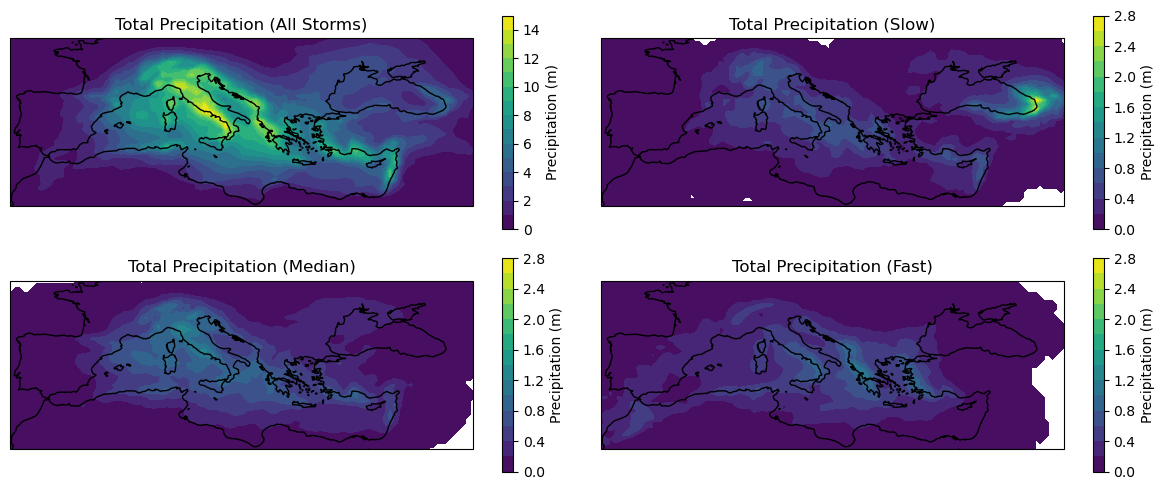

In [65]:
# Visualise precip_all, precip_slow, precip_median, precip_fast in different panels
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 5), subplot_kw={'projection': ccrs.PlateCarree()})
ax = ax.ravel()

for iax in range(4):
    ax[iax].coastlines(resolution='50m', linewidth=1)
    ax[iax].set_xlim(-10, 45)
    ax[iax].set_ylim(30, 50)
    ax[iax].set_xlabel('Longitude')
    ax[iax].set_ylabel('Latitude')

iax = 0
ax[iax].set_title("Total Precipitation (All Storms)")
cf = ax[iax].contourf(lon, lat, precip_all, levels=np.arange(0,16,1), cmap='viridis')
cbar = fig.colorbar(cf, ax=ax[iax], orientation='vertical')
cbar.set_label('Precipitation (m)')

iax = 1
ax[iax].set_title("Total Precipitation (Slow)")
cf = ax[iax].contourf(lon, lat, precip_slow, levels=np.arange(0,3,0.2), cmap='viridis')
cbar = fig.colorbar(cf, ax=ax[iax], orientation='vertical')
cbar.set_label('Precipitation (m)')


iax = 2
ax[iax].set_title("Total Precipitation (Median)")
cf = ax[iax].contourf(lon, lat, precip_median, levels=np.arange(0,3,0.2), cmap='viridis')
cbar = fig.colorbar(cf, ax=ax[iax], orientation='vertical')
cbar.set_label('Precipitation (m)')

iax = 3
ax[iax].set_title("Total Precipitation (Fast)")
cf = ax[iax].contourf(lon, lat, precip_fast, levels=np.arange(0,3,0.2), cmap='viridis')
cbar = fig.colorbar(cf, ax=ax[iax], orientation='vertical')
cbar.set_label('Precipitation (m)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_28622/2282620514.py:14: RuntimeWarning: invalid value encountered in divide
  cf = ax[iax].contourf(lon, lat, precip_all/storm_all, levels=np.arange(0,0.011,0.001), cmap='viridis', extend='max')
/tmp/ipykernel_28622/2282620514.py:20: RuntimeWarning: invalid value encountered in divide
  cf = ax[iax].contourf(lon, lat, precip_slow/storm_slow, levels=np.arange(0,0.011,0.001), cmap='viridis', extend='max')
/tmp/ipykernel_28622/2282620514.py:26: RuntimeWarning: invalid value encountered in divide
  cf = ax[iax].contourf(lon, lat, precip_median/storm_median, levels=np.arange(0,0.011,0.001), cmap='viridis', extend='max')
/tmp/ipykernel_28622/2282620514.py:32: RuntimeWarning: invalid value encountered in divide
  cf = ax[iax].contourf(lon, lat, precip_fast/storm_fast, levels=np.arange(0,0.011,0.001), cmap='viridis', extend='max')


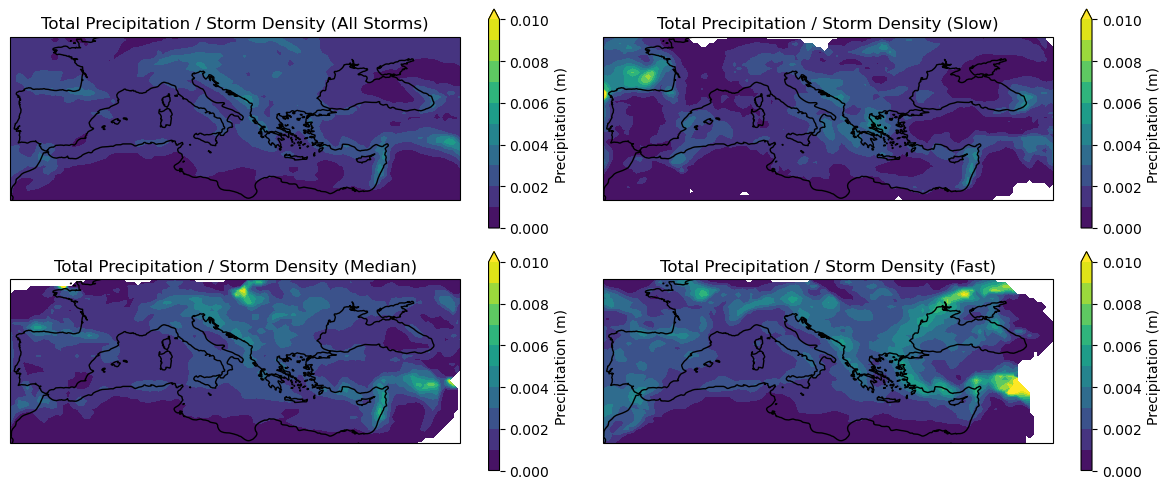

In [72]:
# Visualise precip_all, precip_slow, precip_median, precip_fast in different panels
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 5), subplot_kw={'projection': ccrs.PlateCarree()})
ax = ax.ravel()

for iax in range(4):
    ax[iax].coastlines(resolution='50m', linewidth=1)
    ax[iax].set_xlim(-10, 45)
    ax[iax].set_ylim(30, 50)
    ax[iax].set_xlabel('Longitude')
    ax[iax].set_ylabel('Latitude')

iax = 0
ax[iax].set_title("Total Precipitation / Storm Density (All Storms)")
cf = ax[iax].contourf(lon, lat, precip_all/storm_all, levels=np.arange(0,0.011,0.001), cmap='viridis', extend='max')
cbar = fig.colorbar(cf, ax=ax[iax], orientation='vertical')
cbar.set_label('Precipitation (m)')

iax = 1
ax[iax].set_title("Total Precipitation / Storm Density (Slow)")
cf = ax[iax].contourf(lon, lat, precip_slow/storm_slow, levels=np.arange(0,0.011,0.001), cmap='viridis', extend='max')
cbar = fig.colorbar(cf, ax=ax[iax], orientation='vertical')
cbar.set_label('Precipitation (m)')

iax = 2
ax[iax].set_title("Total Precipitation / Storm Density (Median)")
cf = ax[iax].contourf(lon, lat, precip_median/storm_median, levels=np.arange(0,0.011,0.001), cmap='viridis', extend='max')
cbar = fig.colorbar(cf, ax=ax[iax], orientation='vertical')
cbar.set_label('Precipitation (m)')

iax = 3
ax[iax].set_title("Total Precipitation / Storm Density (Fast)")
cf = ax[iax].contourf(lon, lat, precip_fast/storm_fast, levels=np.arange(0,0.011,0.001), cmap='viridis', extend='max')
cbar = fig.colorbar(cf, ax=ax[iax], orientation='vertical')
cbar.set_label('Precipitation (m)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_28622/3490313264.py:13: RuntimeWarning: invalid value encountered in divide
  cf = ax[iax].contourf(lon, lat, precip_slow/precip_all, levels=np.arange(0,0.55,0.05), cmap='Reds', extend='max')
/tmp/ipykernel_28622/3490313264.py:19: RuntimeWarning: invalid value encountered in divide
  cf = ax[iax].contourf(lon, lat, precip_median/precip_all, levels=np.arange(0,0.55,0.05), cmap='Reds', extend='max')
/tmp/ipykernel_28622/3490313264.py:25: RuntimeWarning: divide by zero encountered in divide
  cf = ax[iax].contourf(lon, lat, precip_fast/precip_all, levels=np.arange(0,0.55,0.05), cmap='Reds', extend='max')
/tmp/ipykernel_28622/3490313264.py:25: RuntimeWarning: invalid value encountered in divide
  cf = ax[iax].contourf(lon, lat, precip_fast/precip_all, levels=np.arange(0,0.55,0.05), cmap='Reds', extend='max')


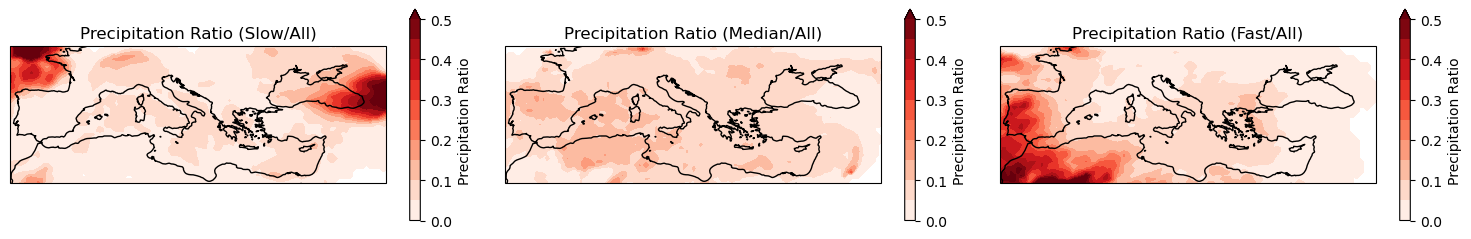

In [61]:
# Visualise ratios precip_slow/precip_all, precip_median/precip_all, precip_fast/precip_all in different panels
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(15, 2.5), subplot_kw={'projection': ccrs.PlateCarree()})

for iax in range(3):
    ax[iax].coastlines(resolution='50m', linewidth=1)
    ax[iax].set_xlim(-10, 45)
    ax[iax].set_ylim(30, 50)
    ax[iax].set_xlabel('Longitude')
    ax[iax].set_ylabel('Latitude')

iax = 0
ax[iax].set_title("Precipitation Ratio (Slow/All)")
cf = ax[iax].contourf(lon, lat, precip_slow/precip_all, levels=np.arange(0,0.55,0.05), cmap='Reds', extend='max')
cbar = fig.colorbar(cf, ax=ax[iax], orientation='vertical')
cbar.set_label('Precipitation Ratio')

iax = 1
ax[iax].set_title("Precipitation Ratio (Median/All)")
cf = ax[iax].contourf(lon, lat, precip_median/precip_all, levels=np.arange(0,0.55,0.05), cmap='Reds', extend='max')
cbar = fig.colorbar(cf, ax=ax[iax], orientation='vertical')
cbar.set_label('Precipitation Ratio')

iax = 2
ax[iax].set_title("Precipitation Ratio (Fast/All)")
cf = ax[iax].contourf(lon, lat, precip_fast/precip_all, levels=np.arange(0,0.55,0.05), cmap='Reds', extend='max')
cbar = fig.colorbar(cf, ax=ax[iax], orientation='vertical')
cbar.set_label('Precipitation Ratio')

plt.tight_layout()
plt.show()

Count events

In [10]:
# Count compounds and extremes (what='all')
if isinstance(months_list[0],list)==False:
    print('Cannot proceed, 2d-list (list of list) of month indices is needed.')
elif what=='all':
    for months in months_list:
        print('Months:',months)
        
        # Select time
        var_time = cfa.timerange_datetime(t_start,t_end,t_int,t_int_u, months)
        
        # Select track dataset
        df_select = cfa.get_storms_sometime(df_tracks,df_clust,cluster_number,id_storm,var_time.astype('datetime64[h]'))
        time_select = cfa.make_var_time(df_select)
        
        # count extremes and compound-extremes per point and time 
        if l_conv==True:
            count = np.zeros((len(lat),len(lon)))
            count_bin = np.zeros((len(lat),len(lon))) # to avoid extra counting
        else:
            count = np.zeros((nvar,len(lat),len(lon)))
            count_bin = np.zeros((nvar,len(lat),len(lon))) # to avoid extra counting
        c_comp = np.zeros((len(lat),len(lon)))
        c_comp_bin = np.zeros((len(lat),len(lon)))     # to avoid extra counting
        # count features
        for lab in labs_ia:
            if l_conv==True:
                vars()['c_extr_'+lab] = np.zeros((len(lat),len(lon)))
            else:
                vars()['c_'+lab] = np.zeros((len(lat),len(lon)))
                vars()['c_extr_'+lab] = np.zeros((nvar,len(lat),len(lon)))
            vars()['c_comp_'+lab] = np.zeros((len(lat),len(lon)))
        
        for tstep in var_time:
            # open dataset
            for vname in np.append(var_list,var_ia):
                if tstep==var_time[0]:
                    ds0, fdir0 = cfa.open_var(vname,tstep,'',[])
                    ds, fdir = ds0, fdir0
                else:
                    # recall dataset
                    ds0, fdir0 = vars()['ds0'+vname], vars()['fdir0'+vname]
                    ds, fdir = cfa.open_var(vname,tstep,fdir0,ds0)
                # process var
                if tstep==var_time[0] or fdir != fdir0:
                    print(vname, tstep)
                    ds = cfa.process_var(ds,vname,[],lat,lon,l_seltime=False)
                    vars()['ds0'+vname], vars()['fdir0'+vname] = ds, fdir

            # count extremes, compounds and (if cyclone is present) impactarea, impactarea+extr, impactarea+compounds
            for i_ia in range(len(var_ia)):
                lab = labs_ia[i_ia]
                if l_conv==True:
                    if i_ia == 0:
                        count, c_comp, vars()['c_extr_'+lab], vars()['c_comp_'+lab] = cfa.count_extr_comp_impactarea_conv(
                            var_list, vars()['ds0'+var_list[0]], vars()['ds0'+var_list[1]], thld[1], 
                            var_ia[i_ia], vars()['ds0'+var_ia[i_ia]], 
                            tstep, time_select,
                            count, c_comp, 
                            vars()['c_extr_'+lab], vars()['c_comp_'+lab])
                    elif tstep in time_select:
                        count_bin, c_comp_bin, vars()['c_extr_'+lab], vars()['c_comp_'+lab] = cfa.count_extr_comp_impactarea_conv(
                            var_list, vars()['ds0'+var_list[0]], vars()['ds0'+var_list[1]], thld[1], 
                            var_ia[i_ia], vars()['ds0'+var_ia[i_ia]], 
                            tstep, time_select,
                            count_bin, c_comp_bin, 
                            vars()['c_extr_'+lab], vars()['c_comp_'+lab])
                else:
                    if i_ia == 0:
                        count, c_comp, vars()['c_'+lab], vars()['c_extr_'+lab], vars()['c_comp_'+lab] = cfa.count_extr_comp_impactarea(
                            var_list, vars()['ds0'+var_list[0]], vars()['ds0'+var_list[1]], thld, 
                            var_ia[i_ia], vars()['ds0'+var_ia[i_ia]], 
                            tstep, time_select,
                            count, c_comp, 
                            vars()['c_'+lab], vars()['c_extr_'+lab], vars()['c_comp_'+lab])
                    elif tstep in time_select:
                        count_bin, c_comp_bin, vars()['c_'+lab], vars()['c_extr_'+lab], vars()['c_comp_'+lab] = cfa.count_extr_comp_impactarea(
                            var_list, vars()['ds0'+var_list[0]], vars()['ds0'+var_list[1]], thld, 
                            var_ia[i_ia], vars()['ds0'+var_ia[i_ia]], 
                            tstep, time_select,
                            count_bin, c_comp_bin, 
                            vars()['c_'+lab], vars()['c_extr_'+lab], vars()['c_comp_'+lab])
                    # do not update count and c_comp arrays from the second iteration (accumulated in *_bin arrays)

        
        # Save counts
        mon_name, [t0_str, t1_str] = cfa.make_labels(months,var_title[:2],qtls,low_lims[:2])
        
        # save to file
        if l_conv==True:
            np.save(out_dir+'count_'+t0_str+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], count)
            np.save(out_dir+'count_'+t0_str+'-and-'+t1_str+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], c_comp)
        else:
            np.save(out_dir+'count_'+t0_str+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], count[0])
            np.save(out_dir+'count_'+t1_str+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], count[1])
            np.save(out_dir+'count_'+t0_str+'-and-'+t1_str+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], c_comp)
        for i_ia in range(len(var_ia)):
            name_ia = names_ia[i_ia]
            lab_ia = labs_ia[i_ia]
            if l_conv==True:
                np.save(out_dir+'count_'+t0_str+'-and-'+name_ia+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], vars()['c_extr_'+lab_ia])
                np.save(out_dir+'count_'+t0_str+'-and-'+t1_str+'-and-'+name_ia+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], vars()['c_comp_'+lab_ia])
            else:
                np.save(out_dir+'count_'+name_ia+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], vars()['c_'+lab_ia])
                np.save(out_dir+'count_'+t0_str+'-and-'+name_ia+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], vars()['c_extr_'+lab_ia][0])
                np.save(out_dir+'count_'+t1_str+'-and-'+name_ia+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], vars()['c_extr_'+lab_ia][1])
                np.save(out_dir+'count_'+t0_str+'-and-'+t1_str+'-and-'+name_ia+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], vars()['c_comp_'+lab_ia])
        print('Data is saved')
else:
    print('Continue to next tab!')

Months: []
swh_6h 1980-01-01T00
windgust_6h 1980-01-01T00
WCBin_cycl 1980-01-01T00
WCBout_cycl 1980-01-01T00
swh_6h 1981-01-01T00
windgust_6h 1981-01-01T00
WCBin_cycl 1981-01-01T00
WCBout_cycl 1981-01-01T00
swh_6h 1982-01-01T00
windgust_6h 1982-01-01T00
WCBin_cycl 1982-01-01T00
WCBout_cycl 1982-01-01T00
swh_6h 1983-01-01T00
windgust_6h 1983-01-01T00
WCBin_cycl 1983-01-01T00
WCBout_cycl 1983-01-01T00
swh_6h 1984-01-01T00
windgust_6h 1984-01-01T00
WCBin_cycl 1984-01-01T00
WCBout_cycl 1984-01-01T00
swh_6h 1985-01-01T00
windgust_6h 1985-01-01T00
WCBin_cycl 1985-01-01T00
WCBout_cycl 1985-01-01T00
swh_6h 1986-01-01T00
windgust_6h 1986-01-01T00
WCBin_cycl 1986-01-01T00
WCBout_cycl 1986-01-01T00
swh_6h 1987-01-01T00
windgust_6h 1987-01-01T00
WCBin_cycl 1987-01-01T00
WCBout_cycl 1987-01-01T00
swh_6h 1988-01-01T00
windgust_6h 1988-01-01T00
WCBin_cycl 1988-01-01T00
WCBout_cycl 1988-01-01T00
swh_6h 1989-01-01T00
windgust_6h 1989-01-01T00
WCBin_cycl 1989-01-01T00
WCBout_cycl 1989-01-01T00
swh_6h 19

In [11]:
# Count extremes (what='all')
if isinstance(months_list[0],list)==False:
    print('Cannot proceed, 2d-list (list of list) of month indices is needed.')
elif what=='extr':
    for months in months_list:
        print('Months:',months)
        
        # Select time
        var_time = cfa.timerange_datetime(t_start,t_end,t_int,t_int_u, months)
        
        # Select track dataset
        df_select = cfa.get_storms_sometime(df_tracks,df_clust,cluster_number,id_storm,var_time.astype('datetime64[h]'))
        time_select = cfa.make_var_time(df_select)
        
        # count extremes and compound-extremes per point and time 
        if l_conv==True:
            count = np.zeros((len(lat),len(lon)))
            count_bin = np.zeros((len(lat),len(lon))) # to avoid extra counting
        else:
            count = np.zeros((nvar,len(lat),len(lon)))
            count_bin = np.zeros((nvar,len(lat),len(lon))) # to avoid extra counting
        c_comp = np.zeros((len(lat),len(lon)))
        c_comp_bin = np.zeros((len(lat),len(lon)))     # to avoid extra counting
        # count features
        for lab in labs_ia:
            if l_conv==True:
                vars()['c_extr_'+lab] = np.zeros((len(lat),len(lon)))
            else:
                vars()['c_'+lab] = np.zeros((len(lat),len(lon)))
                vars()['c_extr_'+lab] = np.zeros((nvar,len(lat),len(lon)))
            vars()['c_comp_'+lab] = np.zeros((len(lat),len(lon)))
        
        for tstep in var_time:
            # open dataset
            for vname in np.append(var_list,var_ia):
                if tstep==var_time[0]:
                    ds0, fdir0 = cfa.open_var(vname,tstep,'',[])
                    ds, fdir = ds0, fdir0
                else:
                    # recall dataset
                    ds0, fdir0 = vars()['ds0'+vname], vars()['fdir0'+vname]
                    ds, fdir = cfa.open_var(vname,tstep,fdir0,ds0)
                # process var
                if tstep==var_time[0] or fdir != fdir0:
                    print(vname, tstep)
                    ds = cfa.process_var(ds,vname,[],lat,lon,l_seltime=False)
                    vars()['ds0'+vname], vars()['fdir0'+vname] = ds, fdir

            # count extremes, compounds and (if cyclone is present) impactarea, impactarea+extr, impactarea+compounds
            for i_ia in range(len(var_ia)):
                lab = labs_ia[i_ia]
                if l_conv==True:
                    if i_ia == 0:
                        count, c_comp, vars()['c_extr_'+lab], vars()['c_comp_'+lab] = cfa.count_extr_comp_impactarea_conv(
                            var_list, vars()['ds0'+var_list[0]], vars()['ds0'+var_list[1]], thld[1], 
                            var_ia[i_ia], vars()['ds0'+var_ia[i_ia]], 
                            tstep, time_select,
                            count, c_comp, 
                            vars()['c_extr_'+lab], vars()['c_comp_'+lab])
                    elif tstep in time_select:
                        count_bin, c_comp_bin, vars()['c_extr_'+lab], vars()['c_comp_'+lab] = cfa.count_extr_comp_impactarea_conv(
                            var_list, vars()['ds0'+var_list[0]], vars()['ds0'+var_list[1]], thld[1], 
                            var_ia[i_ia], vars()['ds0'+var_ia[i_ia]], 
                            tstep, time_select,
                            count_bin, c_comp_bin, 
                            vars()['c_extr_'+lab], vars()['c_comp_'+lab])
                else:
                    if i_ia == 0:
                        count, c_comp, vars()['c_'+lab], vars()['c_extr_'+lab], vars()['c_comp_'+lab] = cfa.count_extr_comp_impactarea(
                            var_list, vars()['ds0'+var_list[0]], vars()['ds0'+var_list[1]], thld, 
                            var_ia[i_ia], vars()['ds0'+var_ia[i_ia]], 
                            tstep, time_select,
                            count, c_comp, 
                            vars()['c_'+lab], vars()['c_extr_'+lab], vars()['c_comp_'+lab])
                    elif tstep in time_select:
                        count_bin, c_comp_bin, vars()['c_'+lab], vars()['c_extr_'+lab], vars()['c_comp_'+lab] = cfa.count_extr_comp_impactarea(
                            var_list, vars()['ds0'+var_list[0]], vars()['ds0'+var_list[1]], thld, 
                            var_ia[i_ia], vars()['ds0'+var_ia[i_ia]], 
                            tstep, time_select,
                            count_bin, c_comp_bin, 
                            vars()['c_'+lab], vars()['c_extr_'+lab], vars()['c_comp_'+lab])
                    # do not update count and c_comp arrays from the second iteration (accumulated in *_bin arrays)

        
        # Save counts
        mon_name, [t0_str, t1_str] = cfa.make_labels(months,var_title[:2],qtls,low_lims[:2])
        
        # save to file
        if l_conv==True:
            np.save(out_dir+'count_'+t0_str+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], count)
            np.save(out_dir+'count_'+t0_str+'-and-'+t1_str+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], c_comp)
        else:
            np.save(out_dir+'count_'+t0_str+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], count[0])
            np.save(out_dir+'count_'+t1_str+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], count[1])
            np.save(out_dir+'count_'+t0_str+'-and-'+t1_str+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], c_comp)
        for i_ia in range(len(var_ia)):
            name_ia = names_ia[i_ia]
            lab_ia = labs_ia[i_ia]
            if l_conv==True:
                np.save(out_dir+'count_'+t0_str+'-and-'+name_ia+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], vars()['c_extr_'+lab_ia])
                np.save(out_dir+'count_'+t0_str+'-and-'+t1_str+'-and-'+name_ia+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], vars()['c_comp_'+lab_ia])
            else:
                np.save(out_dir+'count_'+name_ia+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], vars()['c_'+lab_ia])
                np.save(out_dir+'count_'+t0_str+'-and-'+name_ia+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], vars()['c_extr_'+lab_ia][0])
                np.save(out_dir+'count_'+t1_str+'-and-'+name_ia+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], vars()['c_extr_'+lab_ia][1])
                np.save(out_dir+'count_'+t0_str+'-and-'+t1_str+'-and-'+name_ia+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], vars()['c_comp_'+lab_ia])
        print('Data is saved')
else:
    print('Continue to next tab!')

Continue to next tab!


In [12]:
# Count events (what='feat')
if isinstance(months_list[0],list)==False:
    print('Cannot proceed, 2d-list (list of list) of month indices is needed.')
elif what=='feat':
    for months in months_list:
        print('Months:',months)
        
        # Select time
        var_time = cfa.timerange_datetime(t_start,t_end,t_int,t_int_u, months)
        
        # Select track dataset
        df_select = cfa.get_storms_sometime(df_tracks,df_clust,cluster_number,id_storm,var_time.astype('datetime64[h]'))
        time_select = cfa.make_var_time(df_select)
        
        # count extremes and compound-extremes per point and time 
        count_bin = np.zeros((nvar,len(lat),len(lon))) # to avoid extra counting
        c_comp_bin = np.zeros((len(lat),len(lon)))     # to avoid extra counting
        for lab in labs_ia:
            vars()['c_'+lab] = np.zeros((len(lat),len(lon)))
            vars()['c_extr_'+lab] = np.zeros((nvar,len(lat),len(lon)))
            vars()['c_comp_'+lab] = np.zeros((len(lat),len(lon)))
        
        for tstep in var_time:
            # open dataset
            for vname in np.append(var_list,var_ia):
                if tstep==var_time[0]:
                    ds0, fdir0 = cfa.open_var(vname,tstep,'',[])
                    ds, fdir = ds0, fdir0
                else:
                    # recall dataset
                    ds0, fdir0 = vars()['ds0'+vname], vars()['fdir0'+vname]
                    ds, fdir = cfa.open_var(vname,tstep,fdir0,ds0)
                # process var
                if tstep==var_time[0] or fdir != fdir0:
                    print(vname, tstep)
                    ds = cfa.process_var(ds,vname,[],lat,lon,l_seltime=False)
                    vars()['ds0'+vname], vars()['fdir0'+vname] = ds, fdir
                    
            # count extremes, compounds and (if cyclone is present) impactarea, impactarea+extr, impactarea+compounds
            for i_ia in range(len(var_ia)):
                lab = labs_ia[i_ia]
                if tstep in time_select:
                    count_bin, c_comp_bin, vars()['c_'+lab], vars()['c_extr_'+lab], vars()['c_comp_'+lab] = cfa.count_extr_comp_impactarea(
                        var_list, vars()['ds0'+var_list[0]], vars()['ds0'+var_list[1]], thld, 
                        var_ia[i_ia], vars()['ds0'+var_ia[i_ia]], 
                        tstep, time_select,
                        count_bin, c_comp_bin, 
                        vars()['c_'+lab], vars()['c_extr_'+lab], vars()['c_comp_'+lab])
                    # count_bin and c_comp_bin are dummy accumulations
        
        # Save counts
        mon_name, [t0_str, t1_str] = cfa.make_labels(months,var_title,qtls,low_lims)
        # save to file
        for i_ia in range(len(var_ia)):
            name_ia = names_ia[i_ia]
            lab_ia = labs_ia[i_ia]
            np.save(out_dir+'count_'+name_ia+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], vars()['c_'+lab_ia])
            np.save(out_dir+'count_'+t0_str+'-and-'+name_ia+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], vars()['c_extr_'+lab_ia][0])
            np.save(out_dir+'count_'+t1_str+'-and-'+name_ia+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], vars()['c_extr_'+lab_ia][1])
            np.save(out_dir+'count_'+t0_str+'-and-'+t1_str+'-and-'+name_ia+mon_name+'_'+t_start[:4]+t_start[5:7]+'-'+t_last[:4]+t_last[5:7], vars()['c_comp_'+lab_ia])
        print('Data is saved')
        